In [10]:
!pip install numpy pandas scikit-learn tensorflow seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [2]:
data = pd.read_csv('C:/Users/ADMIN/Downloads/imdb/IMDB Dataset.csv')
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
# Convert labels
le = LabelEncoder()
data['sentiment'] = le.fit_transform(data['sentiment'])


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    data['review'], data['sentiment'], test_size=0.2
)

In [5]:
# Convert text to number
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

In [6]:
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

# Make all reviews same length
X_train = pad_sequences(X_train, maxlen=100)
X_test = pad_sequences(X_test, maxlen=100)

In [7]:
model = Sequential()
model.add(Embedding(5000, 16))
model.add(GlobalAveragePooling1D())
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


In [8]:
# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train model
model.fit(X_train, y_train, epochs=3)

# Test accuracy
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

Epoch 1/3
1250/1250 [==============================] - 7s 3ms/step - loss: 0.4344 - accuracy: 0.8091
Epoch 2/3
1250/1250 [==============================] - 4s 3ms/step - loss: 0.2920 - accuracy: 0.8779
Epoch 3/3
313/313 [==============================] - 1s 2ms/step - loss: 0.3220 - accuracy: 0.8615
Accuracy: 0.8615000247955322


313/313 [==============================] - 1s 3ms/step


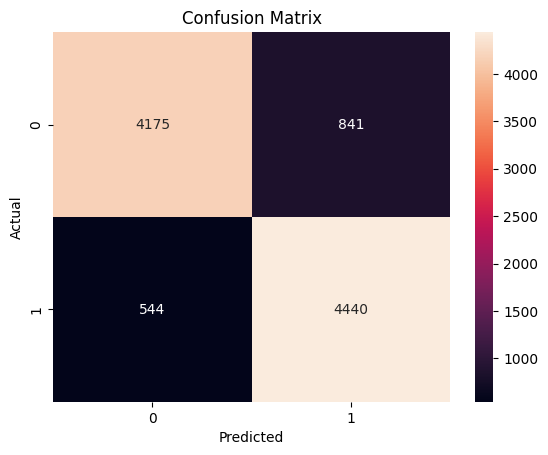


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.83      0.86      5016
           1       0.84      0.89      0.87      4984

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict on test data
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))